# Phase 2: 10-Class MNIST Classification — K-Nearest Neighbors
## Pipeline: Data Loading -> Preprocessing -> Feature Extraction -> Training -> CV Tuning -> Learning Curves -> Evaluation

## 1. Setup & Imports

In [1]:
import sys, os
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from ml_utils import train_test_split, StandardScaler
from ml_utils import classification_report, confusion_matrix
from ml_utils import compute_accuracy, k_fold_split, cross_validate
from ml_utils import plot_learning_curve, evaluate_model, show_misclassified
from sklearn.decomposition import PCA
from skimage.feature import hog
np.random.seed(42)
print("Libraries imported")

Libraries imported


## 2. Configuration

In [2]:
NUM_CLASSES = 10
TRAIN_SIZE, VAL_SIZE, TEST_SIZE = 0.70, 0.15, 0.15
PCA_VARIANCE = 0.95
K_FOLDS = 5
LC_FRACTIONS = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
KNN_K_GRID = [1, 3, 5, 7, 9]
DEFAULT_K = 5

## 3. Data Loading & Preprocessing

In [3]:
X_train_raw = np.load('../../mnist.npz/x_train.npy')
y_train_raw = np.load('../../mnist.npz/y_train.npy')
X_test_raw  = np.load('../../mnist.npz/x_test.npy')
y_test_raw  = np.load('../../mnist.npz/y_test.npy')
X_all = np.concatenate([X_train_raw, X_test_raw], axis=0)
y_all = np.concatenate([y_train_raw, y_test_raw], axis=0)

min_count = min(np.bincount(y_all))
balanced_idx = []
for c in range(NUM_CLASSES):
    c_idx = np.where(y_all == c)[0]
    np.random.shuffle(c_idx)
    balanced_idx.extend(c_idx[:min_count])
balanced_idx = np.array(balanced_idx)
np.random.shuffle(balanced_idx)
X_balanced, y_balanced = X_all[balanced_idx], y_all[balanced_idx]
X_norm = X_balanced / 255.0

X_temp, X_test, y_temp, y_test = train_test_split(
    X_norm, y_balanced, test_size=TEST_SIZE/(TRAIN_SIZE+VAL_SIZE+TEST_SIZE),
    random_state=42, stratify=y_balanced)
val_adj = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_adj, random_state=42, stratify=y_temp)
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 44190, Val: 9470, Test: 9470


### Visualise Dataset Samples
One example per class from the training set.

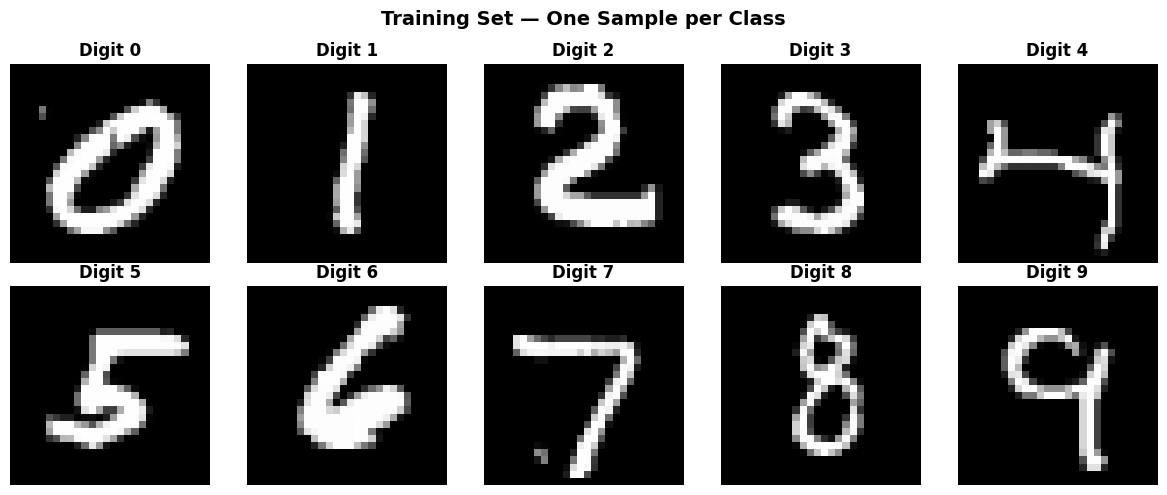

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for c in range(NUM_CLASSES):
    r, col = divmod(c, 5)
    idx = np.where(y_train == c)[0][0]
    axes[r, col].imshow(X_train[idx], cmap='gray')
    axes[r, col].set_title(f'Digit {c}', fontweight='bold')
    axes[r, col].axis('off')
plt.suptitle('Training Set — One Sample per Class', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 4a. Flatten + Scaler + PCA Feature Extraction

In [5]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_flat)
X_val_sc = scaler.transform(X_val_flat)
X_test_sc = scaler.transform(X_test_flat)
pca = PCA(n_components=PCA_VARIANCE, svd_solver='full')
X_train_pca = pca.fit_transform(X_train_sc)
X_val_pca = pca.transform(X_val_sc)
X_test_pca = pca.transform(X_test_sc)
print(f"PCA: {X_train_sc.shape[1]} → {X_train_pca.shape[1]} components ({np.sum(pca.explained_variance_ratio_):.4f} var)")

PCA: 784 → 324 components (0.9503 var)


### Visualise PCA

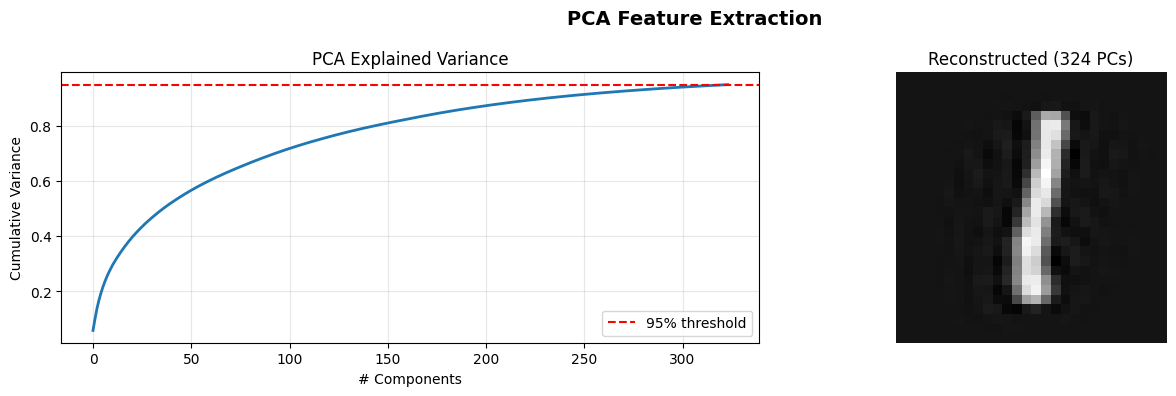

In [6]:
cum_var = np.cumsum(pca.explained_variance_ratio_)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(cum_var, linewidth=2)
axes[0].axhline(PCA_VARIANCE, ls='--', color='red', label=f'{PCA_VARIANCE:.0%} threshold')
axes[0].set_xlabel('# Components'); axes[0].set_ylabel('Cumulative Variance')
axes[0].set_title('PCA Explained Variance'); axes[0].legend(); axes[0].grid(alpha=.3)

recon = pca.inverse_transform(X_train_pca[0:1])
recon = scaler.inverse_transform(recon).reshape(28, 28)
axes[1].imshow(recon, cmap='gray')
axes[1].set_title(f'Reconstructed ({X_train_pca.shape[1]} PCs)'); axes[1].axis('off')
plt.suptitle('PCA Feature Extraction', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 4b. HOG Feature Extraction

**Histogram of Oriented Gradients** captures edge and gradient structure.
Applied to the 2D images (before flattening), then standardised.

In [7]:
def extract_hog(images):
    feats = []
    for img in images:
        f = hog(img, orientations=9, pixels_per_cell=(4,4),
                cells_per_block=(2,2), block_norm='L2-Hys')
        feats.append(f)
    return np.array(feats)

X_train_hog = extract_hog(X_train)
X_val_hog   = extract_hog(X_val)
X_test_hog  = extract_hog(X_test)

scaler_hog = StandardScaler()
X_train_hog_sc = scaler_hog.fit_transform(X_train_hog)
X_val_hog_sc   = scaler_hog.transform(X_val_hog)
X_test_hog_sc  = scaler_hog.transform(X_test_hog)

print(f"HOG feature dim: {X_train_hog_sc.shape[1]}")
print("HOG features ready")

HOG feature dim: 1296
HOG features ready


### Visualise HOG Features

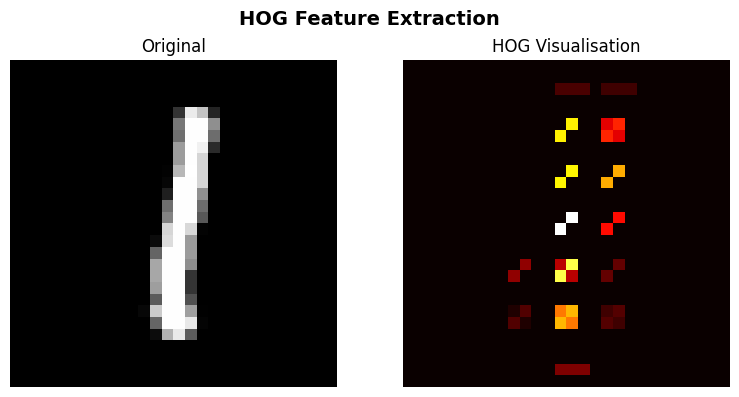

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(X_train[0], cmap='gray')
axes[0].set_title('Original'); axes[0].axis('off')
_, hog_img = hog(X_train[0], orientations=9, pixels_per_cell=(4,4),
                 cells_per_block=(2,2), block_norm='L2-Hys', visualize=True)
axes[1].imshow(hog_img, cmap='hot')
axes[1].set_title('HOG Visualisation'); axes[1].axis('off')
plt.suptitle('HOG Feature Extraction', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 6. KNN Model

Uses **Euclidean distance** and **majority voting**.

In [9]:
class KNearestNeighbors:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train, self.y_train = X, y
        return self

    def _predict_single(self, x):
        dists = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
        k_labels = self.y_train[np.argsort(dists)[:self.k]]
        return np.argmax(np.bincount(k_labels, minlength=10))

    def predict(self, X):
        return np.array([self._predict_single(X[i]) for i in tqdm(range(len(X)), desc='KNN')])

## 7. Baseline Training (PCA Features)

BASELINE KNN (k=5)


KNN: 100%|██████████| 9470/9470 [53:08<00:00,  2.97it/s]  



KNN Baseline (k=5) — Test Acc: 0.9407 (94.07%)
                 precision     recall   f1-score    support

        Digit 0       0.96       0.98       0.97        947
        Digit 1       0.95       0.99       0.97        947
        Digit 2       0.95       0.93       0.94        947
        Digit 3       0.92       0.94       0.93        947
        Digit 4       0.95       0.94       0.94        947
        Digit 5       0.93       0.93       0.93        947
        Digit 6       0.94       0.98       0.96        947
        Digit 7       0.93       0.92       0.92        947
        Digit 8       0.97       0.88       0.92        947
        Digit 9       0.91       0.92       0.91        947

       accuracy                             0.94       9470
      macro avg       0.94       0.94       0.94       9470
   weighted avg       0.94       0.94       0.94       9470



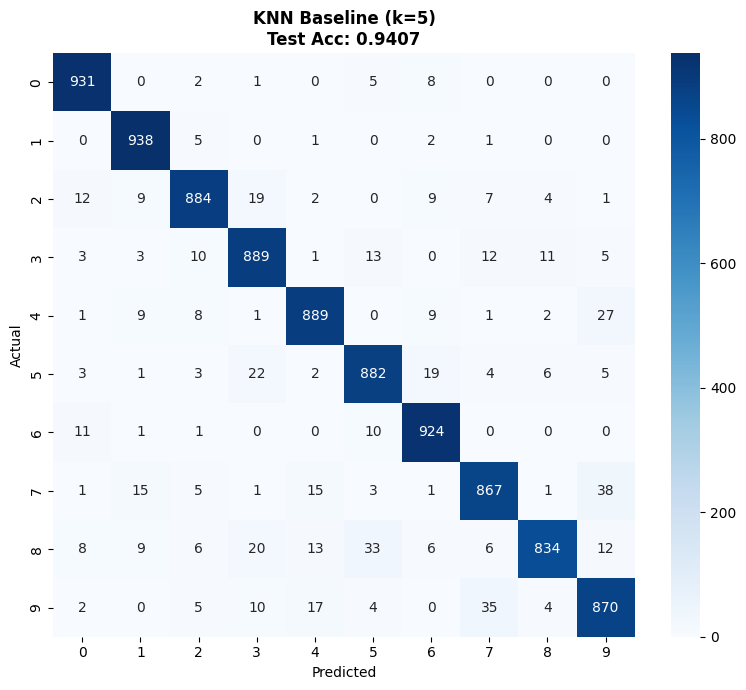

In [10]:
print("BASELINE KNN (k=5)")
knn_base = KNearestNeighbors(k=DEFAULT_K)
knn_base.fit(X_train_pca, y_train)
base_acc = evaluate_model(knn_base, X_test_pca, y_test, "KNN Baseline (k=5)")

KNN: 100%|██████████| 9470/9470 [39:39<00:00,  3.98it/s]  


Misclassified: 562 / 9470


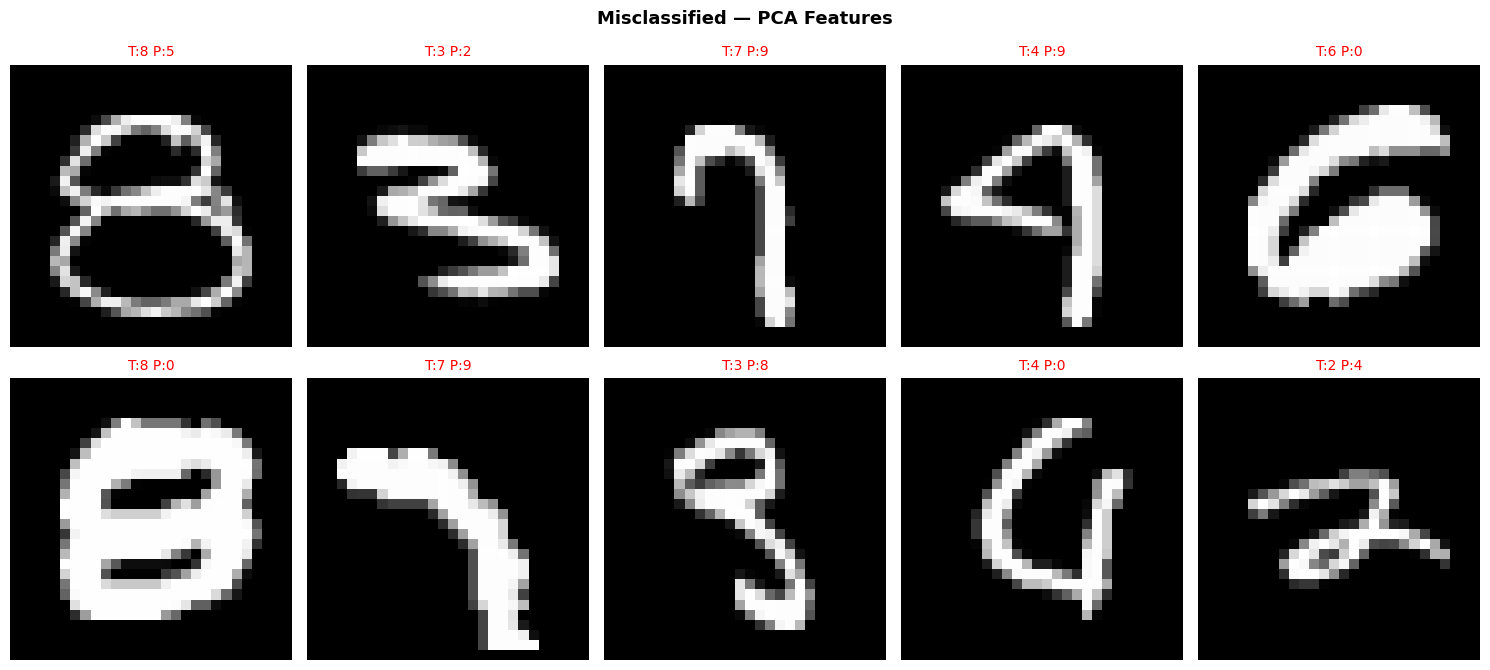

In [11]:
# Note: showing original images for misclassified PCA predictions
preds_pca = knn_base.predict(X_test_pca)
show_misclassified(y_test, preds_pca, X_test,
                   title='Misclassified — PCA Features')

### KNN — Flatten Features


KNN — Flatten Features


KNN: 100%|██████████| 9470/9470 [59:39<00:00,  2.65it/s]  



KNN (Flatten) — Test Acc: 0.9369 (93.69%)
                 precision     recall   f1-score    support

        Digit 0       0.95       0.98       0.97        947
        Digit 1       0.94       0.99       0.97        947
        Digit 2       0.96       0.92       0.94        947
        Digit 3       0.91       0.94       0.93        947
        Digit 4       0.94       0.93       0.94        947
        Digit 5       0.92       0.93       0.93        947
        Digit 6       0.94       0.97       0.96        947
        Digit 7       0.92       0.92       0.92        947
        Digit 8       0.97       0.88       0.92        947
        Digit 9       0.90       0.90       0.90        947

       accuracy                             0.94       9470
      macro avg       0.94       0.94       0.94       9470
   weighted avg       0.94       0.94       0.94       9470



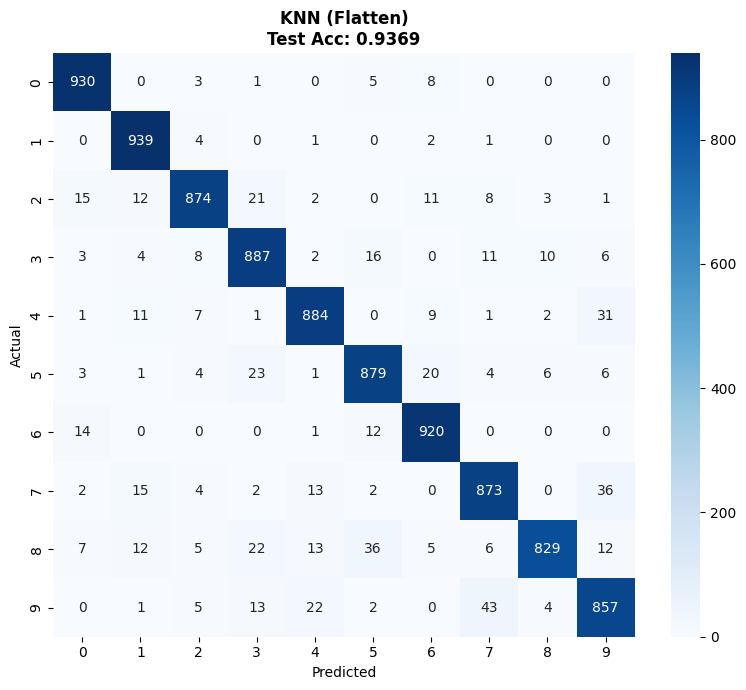

np.float64(0.9368532206969377)

In [12]:
print("\n" + "="*70)
print("KNN — Flatten Features")
print("="*70)
model_flatten = KNearestNeighbors(k=DEFAULT_K)
model_flatten.fit(X_train_sc, y_train)
evaluate_model(model_flatten, X_test_sc, y_test, "KNN (Flatten)")

KNN: 100%|██████████| 9470/9470 [57:30<00:00,  2.74it/s]  


Misclassified: 598 / 9470


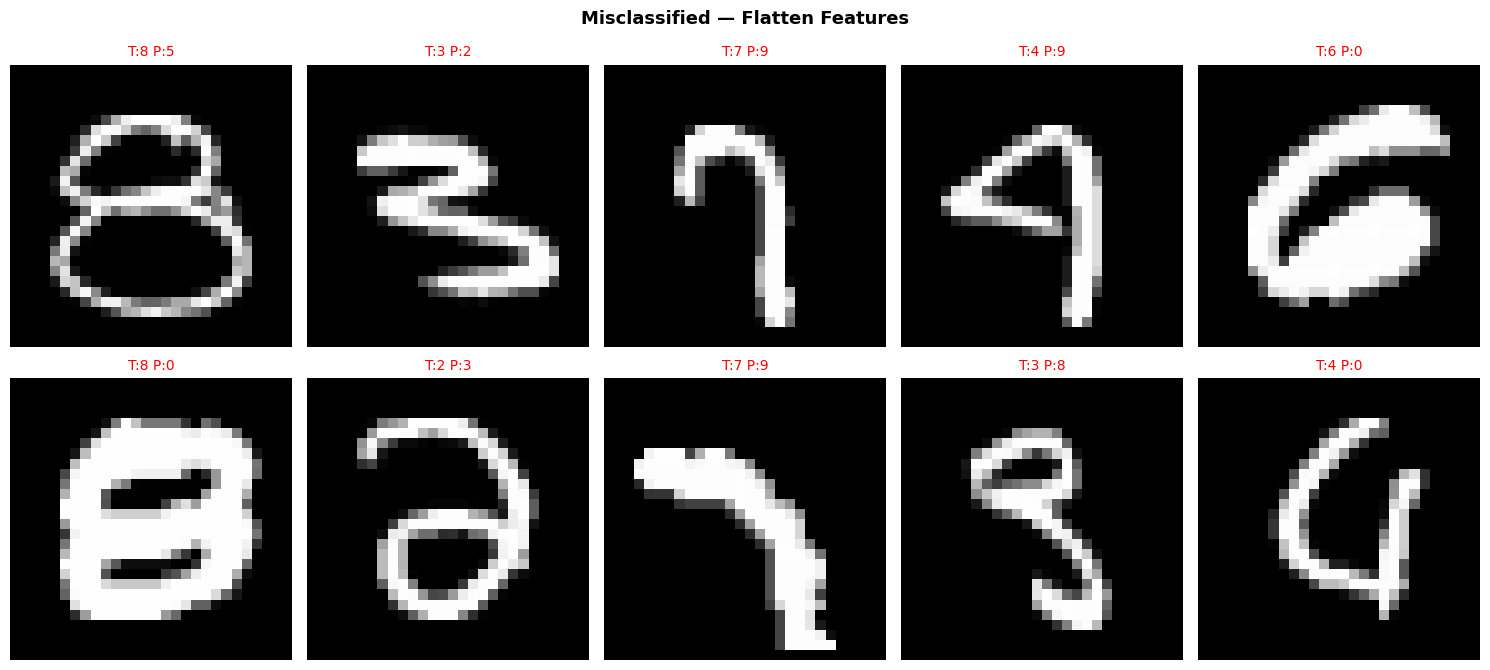

In [13]:
# Note: showing original images for misclassified Flatten predictions
preds_flatten = model_flatten.predict(X_test_sc)
show_misclassified(y_test, preds_flatten, X_test,
                   title='Misclassified — Flatten Features')

### KNN — HOG Features


KNN — HOG Features


KNN: 100%|██████████| 9470/9470 [1:42:49<00:00,  1.53it/s]



KNN (HOG) — Test Acc: 0.9536 (95.36%)
                 precision     recall   f1-score    support

        Digit 0       0.94       0.99       0.96        947
        Digit 1       0.94       0.98       0.96        947
        Digit 2       0.97       0.94       0.95        947
        Digit 3       0.95       0.95       0.95        947
        Digit 4       0.98       0.93       0.95        947
        Digit 5       0.98       0.93       0.96        947
        Digit 6       0.95       0.98       0.97        947
        Digit 7       0.96       0.94       0.95        947
        Digit 8       0.97       0.94       0.95        947
        Digit 9       0.90       0.96       0.93        947

       accuracy                             0.95       9470
      macro avg       0.95       0.95       0.95       9470
   weighted avg       0.95       0.95       0.95       9470



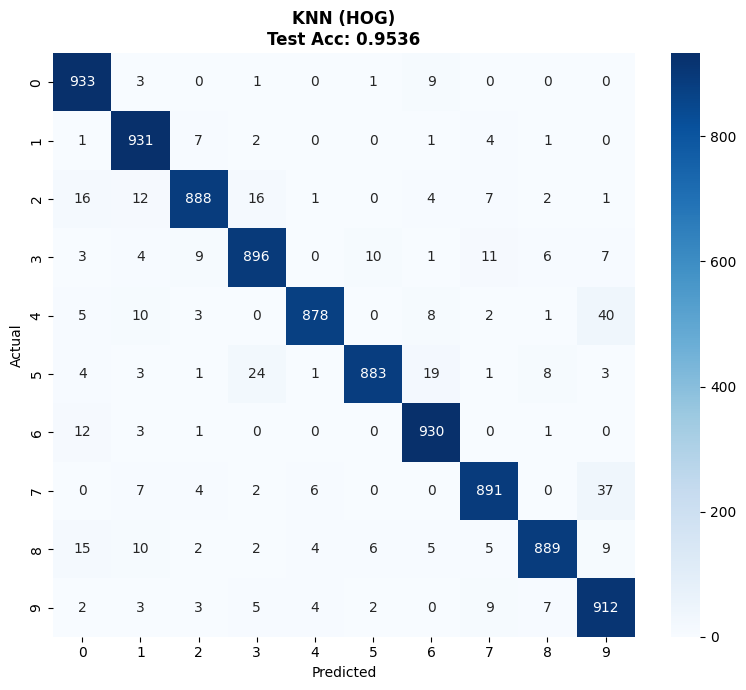

np.float64(0.9536430834213305)

In [14]:
print("\n" + "="*70)
print("KNN — HOG Features")
print("="*70)
model_hog = KNearestNeighbors(k=DEFAULT_K)
model_hog.fit(X_train_hog_sc, y_train)
evaluate_model(model_hog, X_test_hog_sc, y_test, "KNN (HOG)")

KNN: 100%|██████████| 9470/9470 [1:31:12<00:00,  1.73it/s]


Misclassified: 439 / 9470


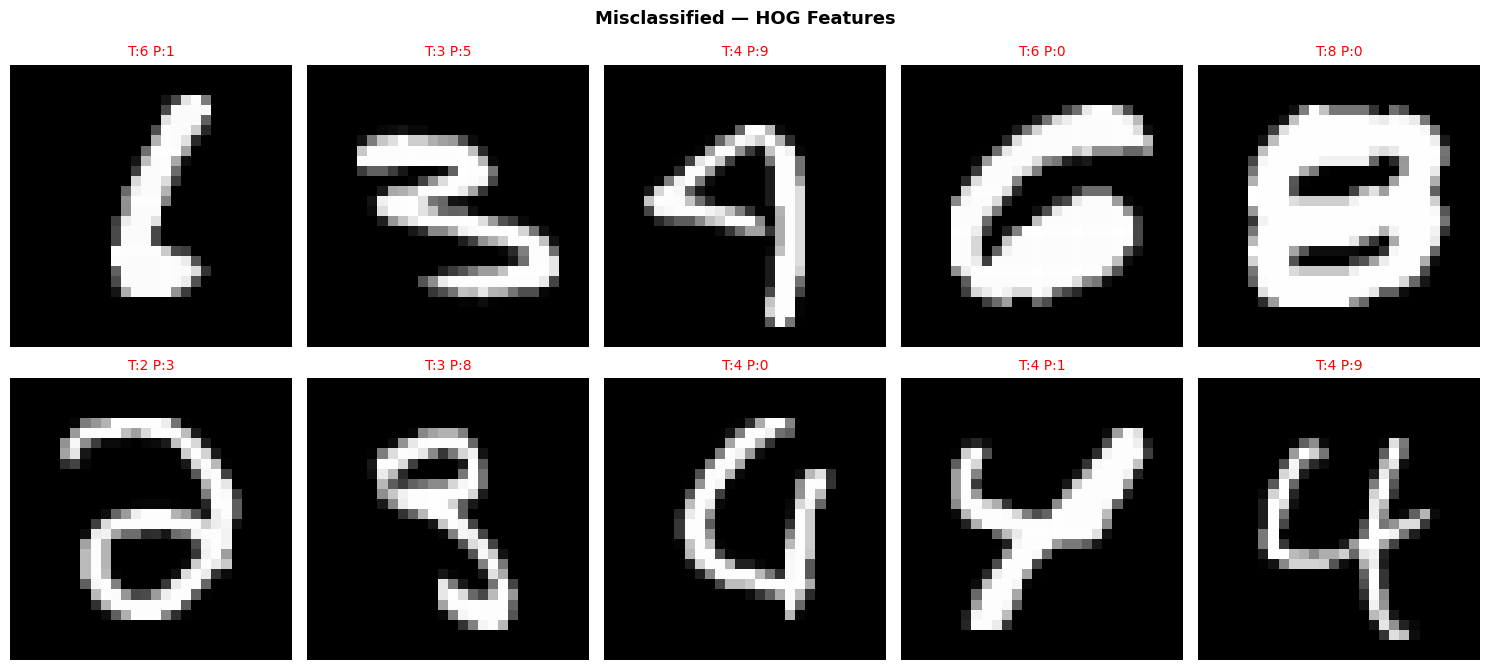

In [15]:
# Note: showing original images for misclassified HOG predictions
preds_hog = model_hog.predict(X_test_hog_sc)
show_misclassified(y_test, preds_hog, X_test,
                   title='Misclassified — HOG Features')

## 8. Hyperparameter Tuning (K-Fold CV)


K=1


KNN: 100%|██████████| 8838/8838 [09:29<00:00, 15.53it/s]


  Fold 1/5: 0.9432


KNN: 100%|██████████| 8838/8838 [09:27<00:00, 15.59it/s]


  Fold 2/5: 0.9409


...

  Fold 3/5: 0.9415


KNN: 100%|██████████| 8838/8838 [07:55<00:00, 18.58it/s]


  Fold 4/5: 0.9416


KNN: 100%|██████████| 8838/8838 [07:57<00:00, 18.50it/s]


  Fold 5/5: 0.9383
  Mean CV: 0.9397

Best K=3 (CV=0.9439)


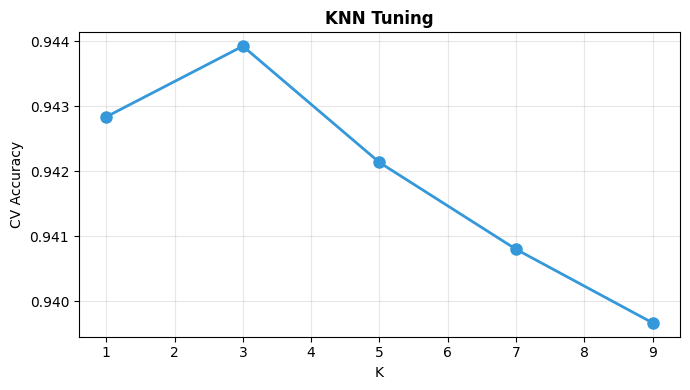

In [16]:
best_acc, best_k = 0, DEFAULT_K
cv_res = []
for kv in KNN_K_GRID:
    print(f"\nK={kv}")
    a = cross_validate(KNearestNeighbors, {'k': kv}, X_train_pca, y_train, k=K_FOLDS)
    cv_res.append((kv, a))
    if a > best_acc: best_acc, best_k = a, kv
print(f"\nBest K={best_k} (CV={best_acc:.4f})")

ks, accs = zip(*cv_res)
plt.figure(figsize=(7,4))
plt.plot(ks, accs, 'o-', color='#3498db', lw=2, ms=8)
plt.xlabel('K'); plt.ylabel('CV Accuracy')
plt.title('KNN Tuning', fontweight='bold'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

KNN: 100%|██████████| 9470/9470 [09:51<00:00, 16.02it/s]



KNN Tuned (k=3) — Test Acc: 0.9428 (94.28%)
                 precision     recall   f1-score    support

        Digit 0       0.94       0.99       0.96        947
        Digit 1       0.96       0.99       0.98        947
        Digit 2       0.95       0.93       0.94        947
        Digit 3       0.92       0.94       0.93        947
        Digit 4       0.95       0.94       0.94        947
        Digit 5       0.94       0.93       0.93        947
        Digit 6       0.95       0.97       0.96        947
        Digit 7       0.94       0.92       0.93        947
        Digit 8       0.96       0.88       0.92        947
        Digit 9       0.92       0.92       0.92        947

       accuracy                             0.94       9470
      macro avg       0.94       0.94       0.94       9470
   weighted avg       0.94       0.94       0.94       9470



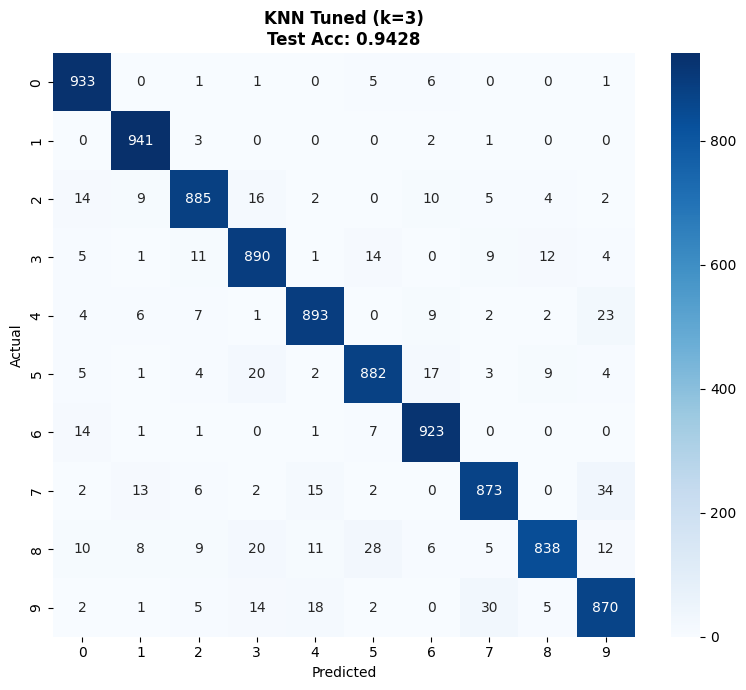

In [17]:
knn_tuned = KNearestNeighbors(k=best_k)
knn_tuned.fit(X_train_pca, y_train)
tuned_acc = evaluate_model(knn_tuned, X_test_pca, y_test, f"KNN Tuned (k={best_k})")

KNN: 100%|██████████| 9470/9470 [09:48<00:00, 16.10it/s]


Misclassified: 542 / 9470


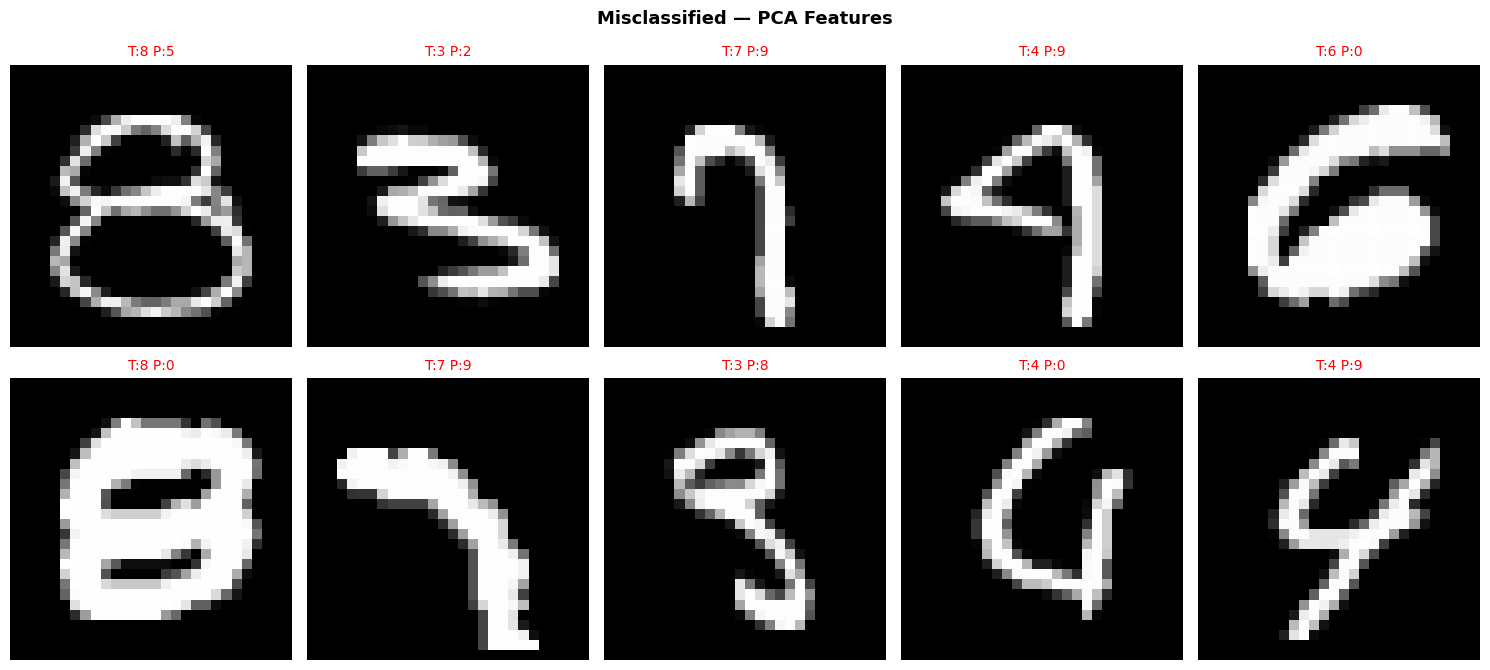

In [18]:
# Note: showing original images for misclassified PCA predictions
preds_pca = knn_tuned.predict(X_test_pca)
show_misclassified(y_test, preds_pca, X_test,
                   title='Misclassified — PCA Features')

## 9. Learning Curve

KNN: 100%|██████████| 9470/9470 [10:26<00:00, 15.11it/s]


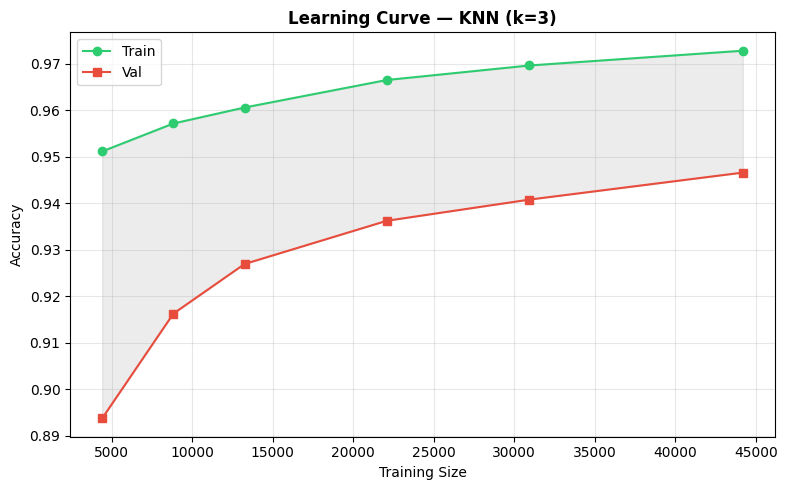

In [19]:
plot_learning_curve(KNearestNeighbors, {'k': best_k}, X_train_pca, y_train,
                    X_val_pca, y_val, LC_FRACTIONS, f"Learning Curve — KNN (k={best_k})")

## 10. Summary

**Analysis**: KNN with small k → high variance (train≈100%, val lower).
Increasing k reduces variance but increases bias.